In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

### Saving Plots as EPS Files

I will now save all the generated plots as Encapsulated PostScript (EPS) files with a resolution of 600 DPI in a new directory named `eps_plots`.

In [151]:
import os

output_dir = 'pdf_plots'

In [152]:
import pandas as pd

file_name = 'data_banknote_authentication.txt'
file_path = f'/content/{file_name}'

try:

    df = pd.read_csv(file_path, header=None)
    print("File loaded successfully into a DataFrame.")
    display(df.head())



except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found at '{file_path}'.\nPlease ensure the file exists and the path is correct.")
except pd.errors.EmptyDataError:
    print("Error: The file is empty.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

File loaded successfully into a DataFrame.


,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [153]:
df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
display(df.head(100))

df.shape

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.80730,-0.446990,0
1,4.54590,8.1674,-2.45860,-1.462100,0
2,3.86600,-2.6383,1.92420,0.106450,0
3,3.45660,9.5228,-4.01120,-3.594400,0
4,0.32924,-4.4552,4.57180,-0.988800,0
...,...,...,...,...,...
95,-0.64472,-4.6062,8.34700,-2.709900,0
96,2.95430,1.0760,0.64577,0.893940,0
97,2.16160,-6.8804,8.15170,-0.081048,0
98,3.82000,10.9279,-4.01120,-5.028400,0


(1372, 5)

In [154]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("DataFrame after shuffling and resetting index:")
display(df_shuffled.head(100))

print("Value counts for 'class' column after shuffling:")
print(df_shuffled['class'].value_counts())

DataFrame after shuffling and resetting index:


,variance,skewness,curtosis,entropy,class
0,1.569100,6.3465,-0.18280,-2.40990,0
1,-0.278020,8.1881,-3.13380,-2.52760,0
2,0.051979,7.0521,-2.05410,-3.15080,0
3,-1.755900,11.9459,3.09460,-4.89780,0
4,2.428700,9.3821,-3.24770,-1.45430,0
...,...,...,...,...,...
95,-3.589500,-6.5720,10.52510,-0.16381,1
96,-4.142900,2.7749,0.68261,-0.71984,1
97,0.274510,9.2186,-3.28630,-4.84480,0
98,2.395200,9.5083,-3.17830,-3.00860,0


Value counts for 'class' column after shuffling:
class
0    762
1    610
Name: count, dtype: int64


In [155]:
df_shuffled.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [156]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


(1372, 5)

In [157]:
df_shuffled.isnull().sum()

df[df.isnull().any(axis=1)]

,variance,skewness,curtosis,entropy,class


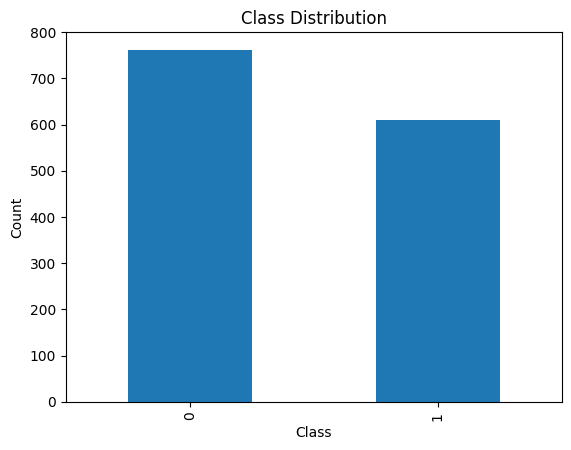

In [158]:
df["class"].value_counts().plot(kind="bar")
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.savefig(os.path.join(output_dir, 'class_distribution_bar_plot.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

In [159]:
df.duplicated().sum()

df.fillna(df.mean(), inplace=True)


df.drop_duplicates(inplace=True)

df.shape

(1348, 5)

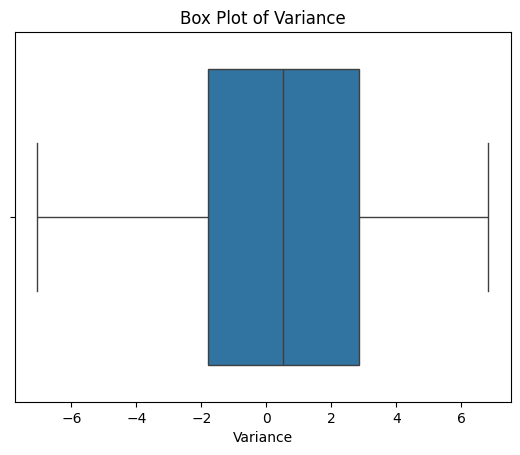

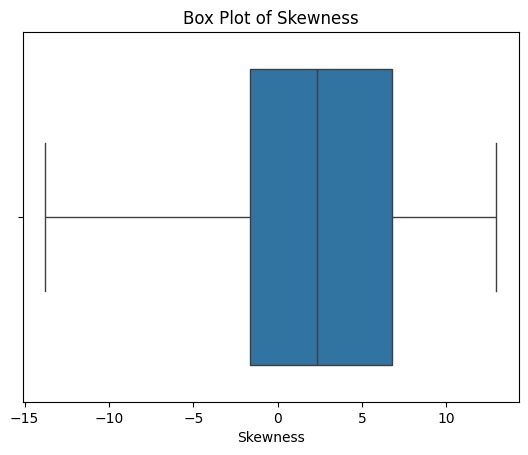

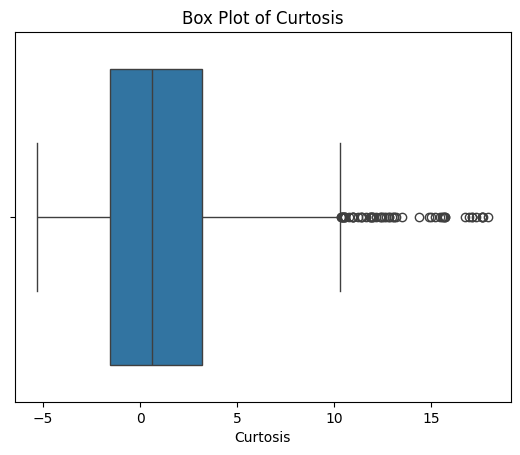

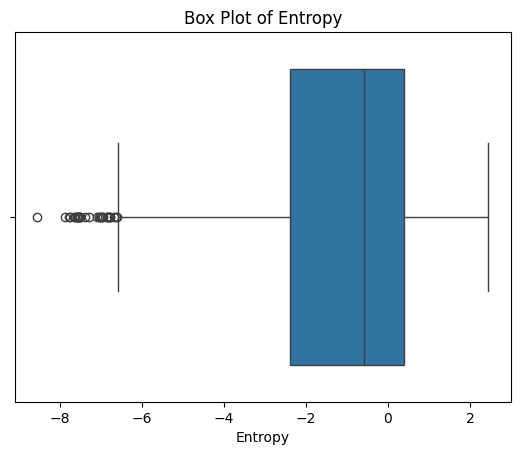

In [160]:
for col in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.savefig(os.path.join(output_dir, f'boxplot_{col}.pdf'), format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

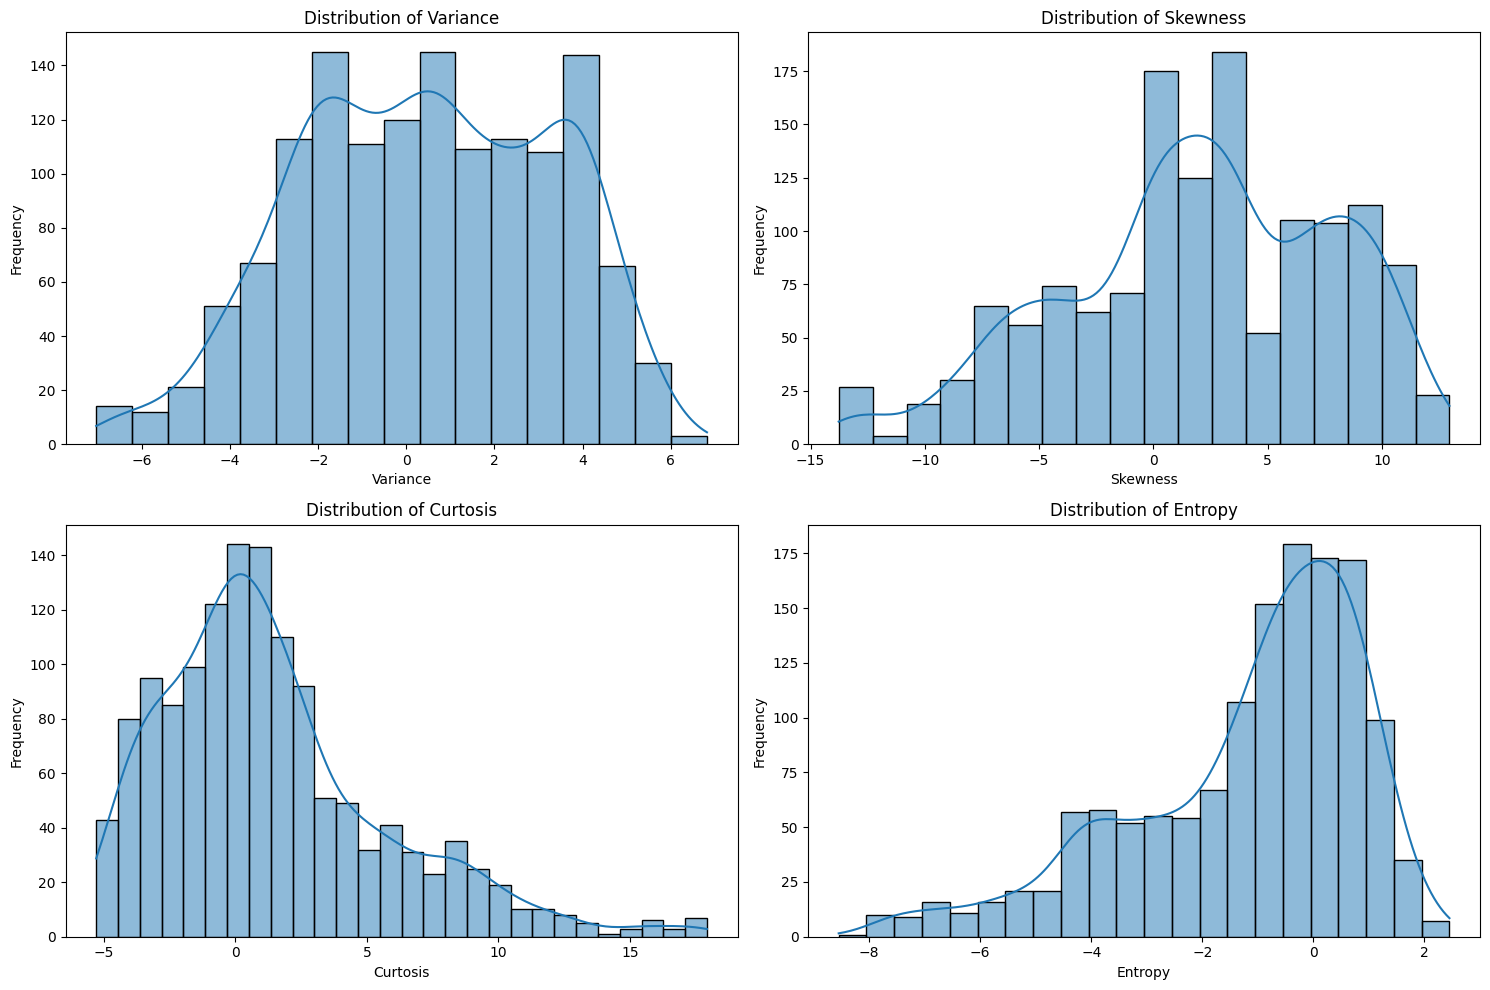

In [161]:
features = ['variance', 'skewness', 'curtosis', 'entropy']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_shuffled[feature], kde=True)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'feature_distributions_histograms.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

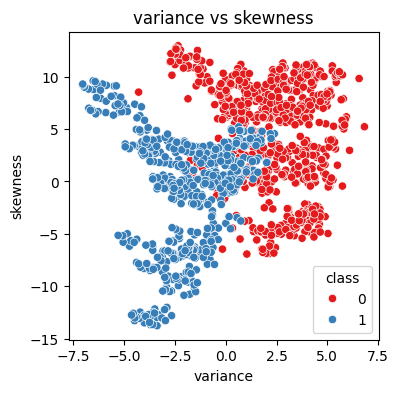

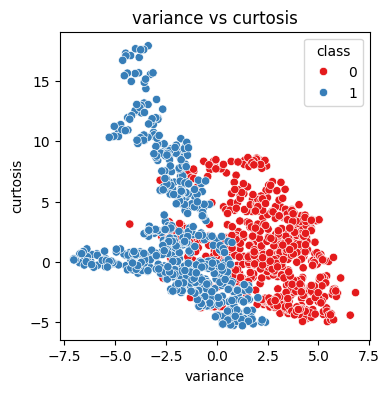

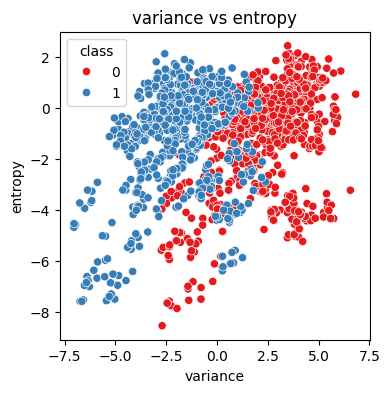

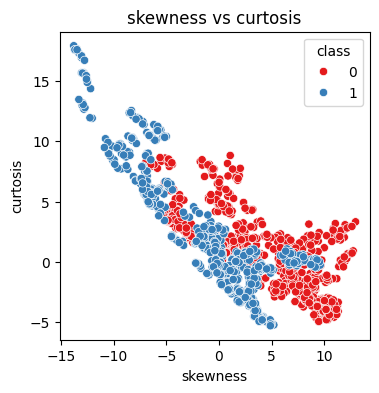

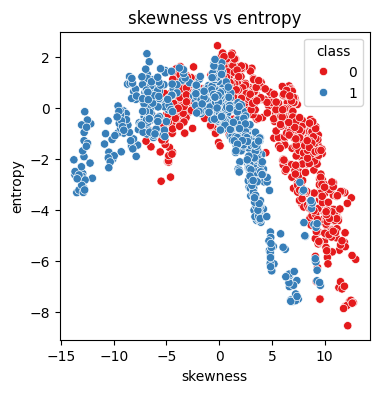

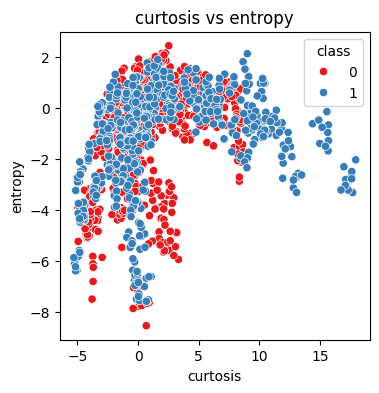

In [162]:
features = ['variance', 'skewness', 'curtosis', 'entropy']

for x, y in combinations(features, 2):
    plt.figure(figsize=(4,4))
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue='class',
        palette='Set1'
    )
    plt.title(f'{x} vs {y}')
    plt.savefig(os.path.join(output_dir, f'scatterplot_{x}_vs_{y}.pdf'), format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

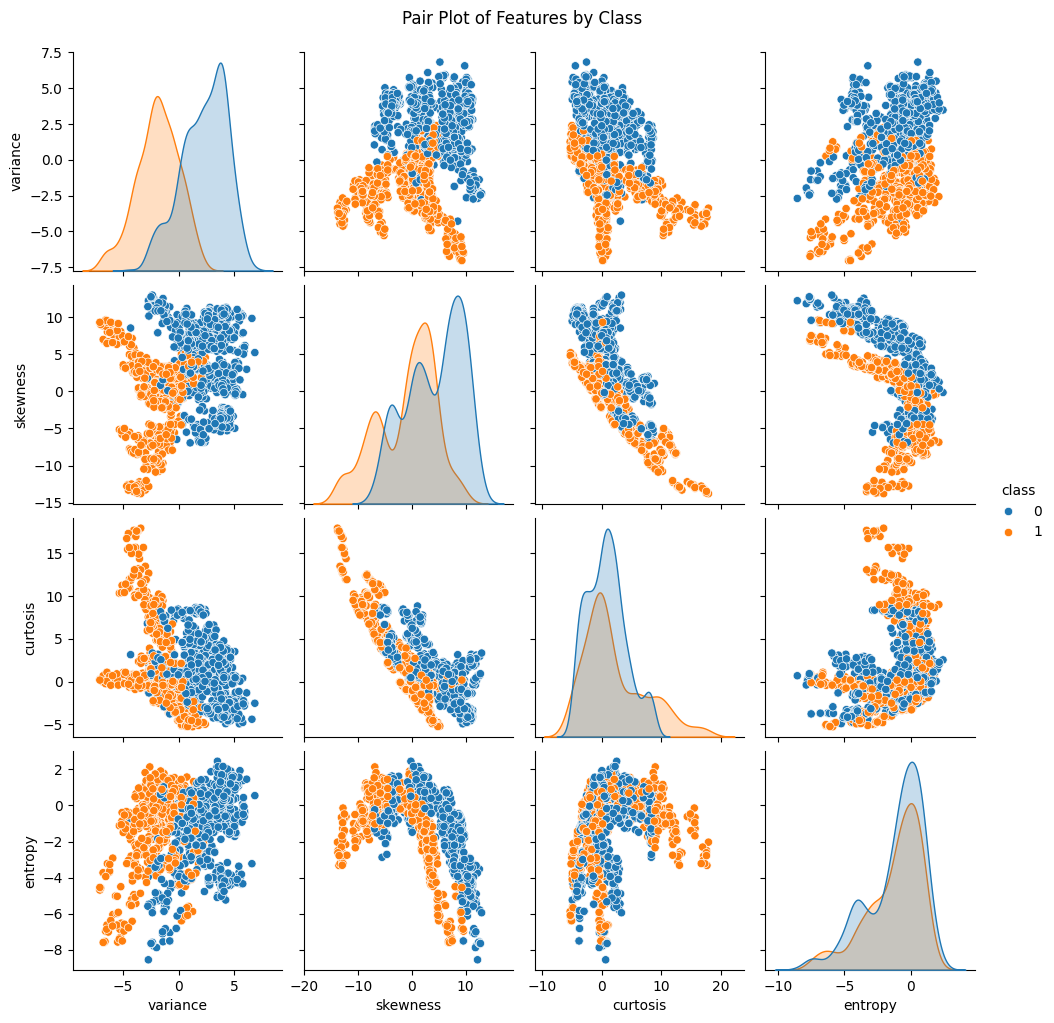

In [163]:
sns.pairplot(df_shuffled, hue='class', diag_kind='kde')
plt.suptitle('Pair Plot of Features by Class', y=1.02)
plt.savefig(os.path.join(output_dir, 'pair_plot_features_by_class.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

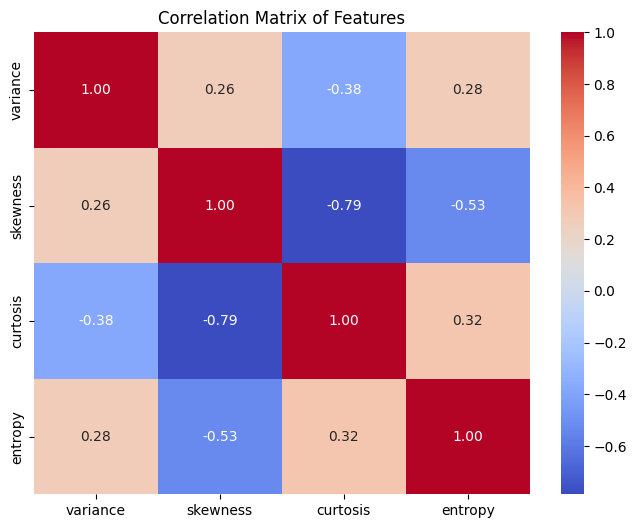

In [164]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_shuffled.drop('class', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.savefig(os.path.join(output_dir, 'correlation_matrix_heatmap.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

In [165]:
X = df_shuffled.drop('class', axis=1)
y = df_shuffled['class']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

display(X.head())
display(y.head())

Features (X) shape: (1372, 4)
Target (y) shape: (1372,)


,variance,skewness,curtosis,entropy
0,1.569100,6.3465,-0.1828,-2.4099
1,-0.278020,8.1881,-3.1338,-2.5276
2,0.051979,7.0521,-2.0541,-3.1508
3,-1.755900,11.9459,3.0946,-4.8978
4,2.428700,9.3821,-3.2477,-1.4543


,class
0,0
1,0
2,0
3,0
4,0


In [166]:
from sklearn.model_selection import train_test_split

y = df_shuffled['class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1097, 4)
X_test shape: (275, 4)
y_train shape: (1097,)
y_test shape: (275,)


In [167]:
output_dir = 'pdf_plots'
if os.path.exists(output_dir):

    import shutil
    shutil.rmtree(output_dir)
    print(f"Removed existing directory: {output_dir}")

os.makedirs(output_dir)
print(f"Created output directory: {output_dir}")

Removed existing directory: pdf_plots
Created output directory: pdf_plots



Summary of Learning Rate Analysis:
Learning Rate: 0.0001, Accuracy: 0.9927
Learning Rate: 0.0010, Accuracy: 0.9855
Learning Rate: 0.0100, Accuracy: 0.9891
Learning Rate: 0.1000, Accuracy: 0.9855
Learning Rate: 0.5000, Accuracy: 0.9891
Learning Rate: 1.0000, Accuracy: 0.9855


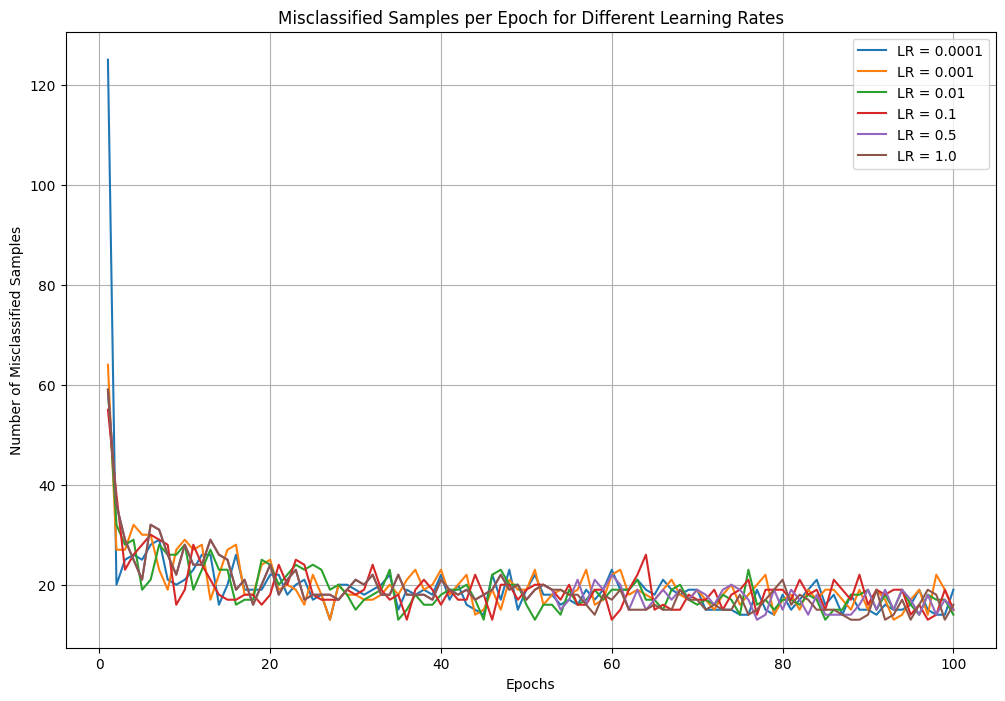

In [168]:
print("\nSummary of Learning Rate Analysis:")
for res in results:
    print(f"Learning Rate: {res['learning_rate']:.4f}, Accuracy: {res['accuracy']:.4f}")

plt.figure(figsize=(12, 8))
for res in results:
    plt.plot(range(1, len(res['errors_per_epoch']) + 1), res['errors_per_epoch'], label=f'LR = {res["learning_rate"]}')

plt.xlabel('Epochs')
plt.ylabel('Number of Misclassified Samples')
plt.title('Misclassified Samples per Epoch for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'misclassified_samples_per_epoch_learning_rates.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

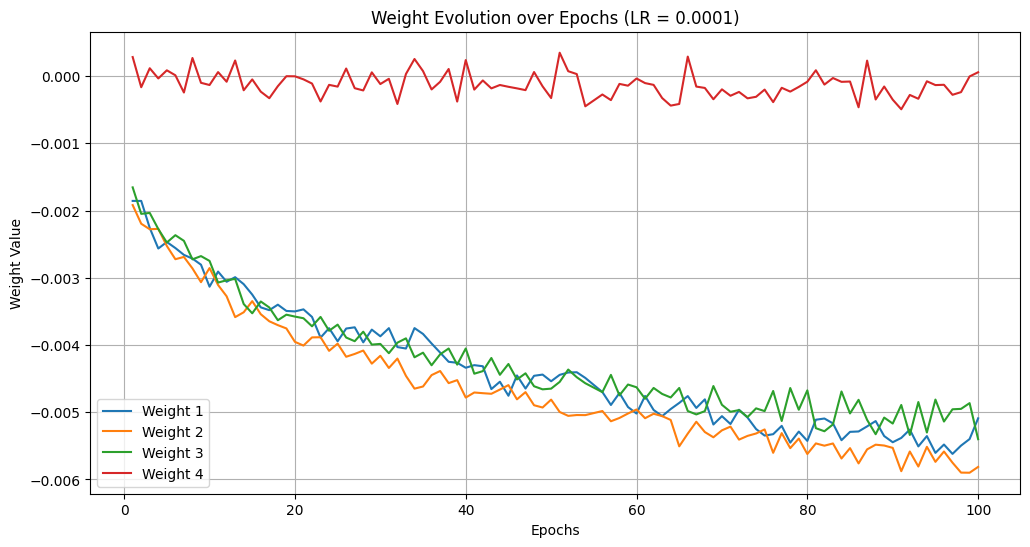

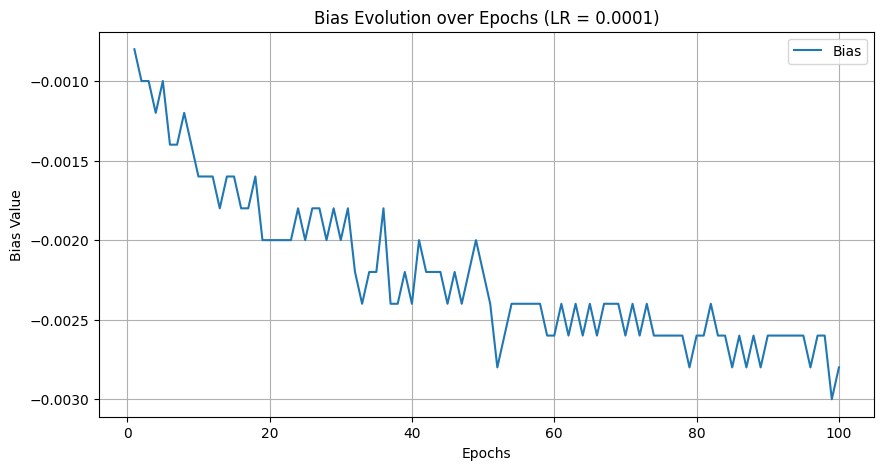

In [169]:
import matplotlib.pyplot as plt
import numpy as np


weights_history_array = np.array(perceptron_custom_best_lr.weight_history)
bias_history_array = np.array(perceptron_custom_best_lr.bias_history)
epochs = range(1, len(weights_history_array) + 1)

plt.figure(figsize=(12, 6))
for i in range(weights_history_array.shape[1]):
    plt.plot(epochs, weights_history_array[:, i], label=f'Weight {i+1}')
plt.xlabel('Epochs')
plt.ylabel('Weight Value')
plt.title(f'Weight Evolution over Epochs (LR = {best_learning_rate})')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'weight_evolution.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(epochs, bias_history_array, label='Bias')
plt.xlabel('Epochs')
plt.ylabel('Bias Value')
plt.title(f'Bias Evolution over Epochs (LR = {best_learning_rate})')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'bias_evolution.pdf'), format='pdf', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

In [170]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

drive_output_dir = '/content/drive/MyDrive/colab_pdf_plots'

output_dir = 'pdf_plots'

if not os.path.exists(drive_output_dir):
    os.makedirs(drive_output_dir)
    print(f"Created Google Drive directory: {drive_output_dir}")
else:
    print(f"Google Drive directory already exists: {drive_output_dir}")

if os.path.exists(output_dir):
    for item in os.listdir(output_dir):
        s = os.path.join(output_dir, item)
        d = os.path.join(drive_output_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, symlinks=True, ignore=None)
        else:
            shutil.copy2(s, d)
    print(f"Successfully copied all PDF plots from '{output_dir}' to '{drive_output_dir}'.")
else:
    print(f"Local directory '{output_dir}' does not exist, no plots to copy.")

print(f"You can now find your plots in Google Drive at: {drive_output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive directory already exists: /content/drive/MyDrive/colab_pdf_plots
Successfully copied all PDF plots from 'pdf_plots' to '/content/drive/MyDrive/colab_pdf_plots'.
You can now find your plots in Google Drive at: /content/drive/MyDrive/colab_pdf_plots


In [171]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled (first 5 rows):\n", X_train_scaled[:5])
print("\nX_test_scaled (first 5 rows):\n", X_test_scaled[:5])

X_train_scaled (first 5 rows):
 [[-2.42805394  1.16647265 -0.2613395  -1.29174966]
 [-1.55602305 -1.76639464  2.60605569 -0.11049665]
 [ 0.74498189  0.23776024  0.16097456  0.69555789]
 [-1.32606958 -0.39535615  0.18450436  0.85322055]
 [-1.32428428 -0.27811116  0.30529689  0.39000112]]

X_test_scaled (first 5 rows):
 [[ 1.44971979 -1.10415201  0.42953796  0.57089002]
 [-0.892207   -0.34881322  0.14147979  1.20828171]
 [ 0.47823727 -0.5310703   0.04679759  0.44561146]
 [-0.32761855  0.15320073 -0.74054734 -0.49977375]
 [-0.81890474 -1.3969082   0.99939064  0.79822458]]


In [172]:
y_pred_custom = perceptron.predict(X_test_scaled)


accuracy_custom = accuracy_score(y_test, y_pred_custom)
precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom)
class_report_custom = classification_report(y_test, y_pred_custom)

print(f"Custom Perceptron Accuracy: {accuracy_custom:.4f}")
print(f"Custom Perceptron Precision: {precision_custom:.4f}")
print(f"Custom Perceptron Recall: {recall_custom:.4f}")
print(f"Custom Perceptron F1-score: {f1_custom:.4f}")

print("\nCustom Perceptron Confusion Matrix:")
display(pd.DataFrame(conf_matrix_custom, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nCustom Perceptron Classification Report:")
print(class_report_custom)

Custom Perceptron Accuracy: 0.9927
Custom Perceptron Precision: 1.0000
Custom Perceptron Recall: 0.9836
Custom Perceptron F1-score: 0.9917

Custom Perceptron Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,153,0
Actual 1,2,120



Custom Perceptron Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       153
           1       1.00      0.98      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [173]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
results = []

print("\n--- Analyzing different Learning Rates ---")

for lr in learning_rates:
    print(f"\nTraining Perceptron with learning_rate = {lr}")
    perceptron_lr = CustomPerceptron(learning_rate=lr, n_iterations=100)
    perceptron_lr.fit(X_train_scaled, y_train)


    y_pred_lr = perceptron_lr.predict(X_test_scaled)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)

    results.append({
        'learning_rate': lr,
        'accuracy': accuracy_lr,
        'errors_per_epoch': perceptron_lr.errors
    })
    print(f"Accuracy for learning_rate {lr}: {accuracy_lr:.4f}")

print("\n--- Learning Rate Analysis Complete ---")


--- Analyzing different Learning Rates ---

Training Perceptron with learning_rate = 0.0001
Epoch   1/100 - Misclassified samples: 159
Epoch   2/100 - Misclassified samples:  23
Epoch   3/100 - Misclassified samples:  30
Epoch   4/100 - Misclassified samples:  23
Epoch   5/100 - Misclassified samples:  28
Epoch   6/100 - Misclassified samples:  23
Epoch   7/100 - Misclassified samples:  17
Epoch   8/100 - Misclassified samples:  25
Epoch   9/100 - Misclassified samples:  20
Epoch  10/100 - Misclassified samples:  20
Epoch  11/100 - Misclassified samples:  18
Epoch  12/100 - Misclassified samples:  24
Epoch  13/100 - Misclassified samples:  27
Epoch  14/100 - Misclassified samples:  24
Epoch  15/100 - Misclassified samples:  24
Epoch  16/100 - Misclassified samples:  25
Epoch  17/100 - Misclassified samples:  24
Epoch  18/100 - Misclassified samples:  19
Epoch  19/100 - Misclassified samples:  16
Epoch  20/100 - Misclassified samples:  20
Epoch  21/100 - Misclassified samples:  23
Epoc

### Task 8: Compare Implementations

Finally, let's compare the performance of our custom Perceptron implementation with Scikit-learn's built-in Perceptron model. We will use the optimal learning rate identified from our analysis for the custom Perceptron.

In [174]:
from sklearn.linear_model import Perceptron

best_lr_result = max(results, key=lambda x: x['accuracy'])
best_learning_rate = best_lr_result['learning_rate']

print(f"\n--- Comparing Custom Perceptron (LR={best_learning_rate}) with Scikit-learn Perceptron ---")

print("\nCustom Perceptron with best learning rate:")
perceptron_custom_best_lr = CustomPerceptron(learning_rate=best_learning_rate, n_iterations=100)
perceptron_custom_best_lr.fit(X_train_scaled, y_train)
y_pred_custom_best_lr = perceptron_custom_best_lr.predict(X_test_scaled)

accuracy_custom_best_lr = accuracy_score(y_test, y_pred_custom_best_lr)
precision_custom_best_lr = precision_score(y_test, y_pred_custom_best_lr)
recall_custom_best_lr = recall_score(y_test, y_pred_custom_best_lr)
f1_custom_best_lr = f1_score(y_test, y_pred_custom_best_lr)
conf_matrix_custom_best_lr = confusion_matrix(y_test, y_pred_custom_best_lr)
class_report_custom_best_lr = classification_report(y_test, y_pred_custom_best_lr)

print(f"Custom Perceptron (LR={best_learning_rate}) Accuracy: {accuracy_custom_best_lr:.4f}")
print(f"Custom Perceptron (LR={best_learning_rate}) Precision: {precision_custom_best_lr:.4f}")
print(f"Custom Perceptron (LR={best_learning_rate}) Recall: {recall_custom_best_lr:.4f}")
print(f"Custom Perceptron (LR={best_learning_rate}) F1-score: {f1_custom_best_lr:.4f}")
print("\nCustom Perceptron (LR={best_learning_rate}) Confusion Matrix:")
display(pd.DataFrame(conf_matrix_custom_best_lr, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))
print("\nCustom Perceptron (LR={best_learning_rate}) Classification Report:")
print(class_report_custom_best_lr)


print("\nScikit-learn Perceptron:")

perceptron_sklearn = Perceptron(eta0=best_learning_rate, random_state=42, max_iter=100)
perceptron_sklearn.fit(X_train_scaled, y_train)
y_pred_sklearn = perceptron_sklearn.predict(X_test_scaled)

accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
precision_sklearn = precision_score(y_test, y_pred_sklearn)
recall_sklearn = recall_score(y_test, y_pred_sklearn)
f1_sklearn = f1_score(y_test, y_pred_sklearn)
conf_matrix_sklearn = confusion_matrix(y_test, y_pred_sklearn)
class_report_sklearn = classification_report(y_test, y_pred_sklearn)

print(f"Scikit-learn Perceptron Accuracy: {accuracy_sklearn:.4f}")
print(f"Scikit-learn Perceptron Precision: {precision_sklearn:.4f}")
print(f"Scikit-learn Perceptron Recall: {recall_sklearn:.4f}")
print(f"Scikit-learn Perceptron F1-score: {f1_sklearn:.4f}")
print("\nScikit-learn Perceptron Confusion Matrix:")
display(pd.DataFrame(conf_matrix_sklearn, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))
print("\nScikit-learn Perceptron Classification Report:")
print(class_report_sklearn)

print("\n--- Comparison Complete ---")


--- Comparing Custom Perceptron (LR=0.001) with Scikit-learn Perceptron ---

Custom Perceptron with best learning rate:
Epoch   1/100 - Misclassified samples:  59
Epoch   2/100 - Misclassified samples:  35
Epoch   3/100 - Misclassified samples:  34
Epoch   4/100 - Misclassified samples:  24
Epoch   5/100 - Misclassified samples:  18
Epoch   6/100 - Misclassified samples:  23
Epoch   7/100 - Misclassified samples:  27
Epoch   8/100 - Misclassified samples:  27
Epoch   9/100 - Misclassified samples:  26
Epoch  10/100 - Misclassified samples:  29
Epoch  11/100 - Misclassified samples:  15
Epoch  12/100 - Misclassified samples:  21
Epoch  13/100 - Misclassified samples:  26
Epoch  14/100 - Misclassified samples:  19
Epoch  15/100 - Misclassified samples:  24
Epoch  16/100 - Misclassified samples:  22
Epoch  17/100 - Misclassified samples:  23
Epoch  18/100 - Misclassified samples:  21
Epoch  19/100 - Misclassified samples:  23
Epoch  20/100 - Misclassified samples:  20
Epoch  21/100 - Mis

,Predicted 0,Predicted 1
Actual 0,153,0
Actual 1,4,118



Custom Perceptron (LR={best_learning_rate}) Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       153
           1       1.00      0.97      0.98       122

    accuracy                           0.99       275
   macro avg       0.99      0.98      0.99       275
weighted avg       0.99      0.99      0.99       275


Scikit-learn Perceptron:
Scikit-learn Perceptron Accuracy: 1.0000
Scikit-learn Perceptron Precision: 1.0000
Scikit-learn Perceptron Recall: 1.0000
Scikit-learn Perceptron F1-score: 1.0000

Scikit-learn Perceptron Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,153,0
Actual 1,0,122



Scikit-learn Perceptron Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


--- Comparison Complete ---
